<a href="https://colab.research.google.com/github/gabriels3t/Classificacao-de-Jatos-utilizando-o-dataset-hls4ml-lhc-com-MLP-e-CNN--trabalho-/blob/main/rede_neural_trabalho.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
if 'google.colab' in str(get_ipython()):
    !git clone https://github.com/gabriels3t/Classificacao-de-Jatos-utilizando-o-dataset-hls4ml-lhc-com-MLP-e-CNN--trabalho-.git
    import os as os
    os.chdir('./Classificacao-de-Jatos-utilizando-o-dataset-hls4ml-lhc-com-MLP-e-CNN--trabalho-')

Cloning into 'Classificacao-de-Jatos-utilizando-o-dataset-hls4ml-lhc-com-MLP-e-CNN--trabalho-'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 62 (delta 8), reused 15 (delta 2), pack-reused 34 (from 1)
Receiving objects: 100% (62/62), 604.06 MiB | 41.90 MiB/s, done.
Resolving deltas: 100% (8/8), done.
Updating files: 100% (37/37), done.
Filtering content: 100% (4/4), 920.61 MiB | 47.62 MiB/s, done.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
treino_df_arrumado = pd.read_csv('data/treino_preprocessado.csv')
teste_df_arrumado = pd.read_csv('data/teste_preprocessado.csv')

In [5]:
treino_df_arrumado.head()

,$p_{z}$ [Gev],$p_{T}$ [GeV],$\eta$,Rotated $\eta$,$\phi$,Rotated $\phi$,$\Delta R$,tipo
0,75.105600,403.669620,0.185000,-0.000000,-0.245124,0.000000,0.006959,0.0
1,25.297071,137.847630,0.182500,-0.006112,-0.237621,-0.005019,0.009463,0.0
2,9.730256,55.318676,0.175000,0.002193,-0.265135,0.022262,0.028418,0.0
3,9.119686,51.982910,0.174549,-0.011119,-0.240856,0.001954,0.016519,0.0
4,8.759169,46.442963,0.187500,0.006113,-0.252628,0.005020,0.011507,0.0


In [21]:
treino_df_arrumado['tipo'].unique()

array([0., 1., 2., 3., 4.])

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 2. Separar features (X) e target (y)
X = treino_df_arrumado.drop(columns=['tipo'])
y = treino_df_arrumado['tipo']

X_test = teste_df_arrumado.drop(columns=['tipo'])  # só remove o target no teste também

# 3. Criar divisão de validação (ex.: 20% validação)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 4. Normalizar com StandardScaler (fit APENAS no treino)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

In [22]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

input_dim = X_train.shape[1]  # número de features

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(20, activation='sigmoid'),
    layers.Dense(5, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 20)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 265 (1.04 KB)

 Trainable params: 265 (1.04 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
from tensorflow.keras.callbacks import EarlyStopping

# callback para parar cedo se não melhorar após 6 épocas
early_stop = EarlyStopping(
    monitor='accuracy',   # monitorar a métrica de validação
    patience=6,           # quantas épocas esperar sem melhora
    restore_best_weights=True # restaurar melhor versão
)


In [23]:
from tensorflow.keras.callbacks import EarlyStopping

# callback para parar cedo se não melhorar após 6 épocas
early_stop = EarlyStopping(
    monitor='accuracy',   # monitorar a métrica de validação
    patience=6,           # quantas épocas esperar sem melhora
    restore_best_weights=True # restaurar melhor versão
)

history = model.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=128,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/150
31875/31875 ━━━━━━━━━━━━━━━━━━━━ 105s 3ms/step - accuracy: 0.3409 - loss: 1.4844 - val_accuracy: 0.4035 - val_loss: 1.3947
Epoch 2/150
31875/31875 ━━━━━━━━━━━━━━━━━━━━ 127s 3ms/step - accuracy: 0.4083 - loss: 1.3879 - val_accuracy: 0.4209 - val_loss: 1.3607
Epoch 3/150
31875/31875 ━━━━━━━━━━━━━━━━━━━━ 113s 4ms/step - accuracy: 0.4249 - loss: 1.3541 - val_accuracy: 0.4379 - val_loss: 1.3323
Epoch 4/150
31875/31875 ━━━━━━━━━━━━━━━━━━━━ 124s 4ms/step - accuracy: 0.4390 - loss: 1.3302 - val_accuracy: 0.4453 - val_loss: 1.3201
Epoch 5/150
31875/31875 ━━━━━━━━━━━━━━━━━━━━ 107s 3ms/step - accuracy: 0.4448 - loss: 1.3190 - val_accuracy: 0.4467 - val_loss: 1.3144
Epoch 6/150
31875/31875 ━━━━━━━━━━━━━━━━━━━━ 87s 3ms/step - accuracy: 0.4478 - loss: 1.3145 - val_accuracy: 0.4489 - val_loss: 1.3116
Epoch 7/150
31875/31875 ━━━━━━━━━━━━━━━━━━━━ 86s 3ms/step - accuracy: 0.4485 - loss: 1.3119 - val_accuracy: 0.4488 - val_loss: 1.3099
Epoch 8/150
31875/31875 ━━━━━━━━━━━━━━━━━━━━ 142s 3ms/ste

In [ ]:
# Salvar modelo no formato Keras (.keras)
model.save("modelo_classificacao.keras")

31875/31875 ━━━━━━━━━━━━━━━━━━━━ 41s 1ms/step


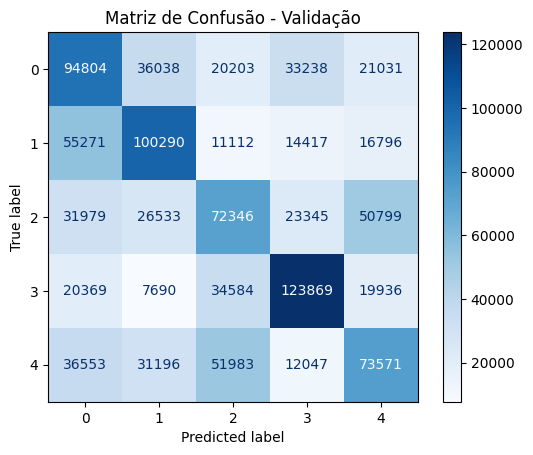

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Predições no conjunto de validação
y_val_pred = model.predict(X_val_scaled)
y_val_pred_classes = np.argmax(y_val_pred, axis=1)

# Matriz de confusão
cm = confusion_matrix(y_val, y_val_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusão - Validação")
plt.show()


In [26]:
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.utils import to_categorical

y_val_onehot = to_categorical(y_val, num_classes=5)


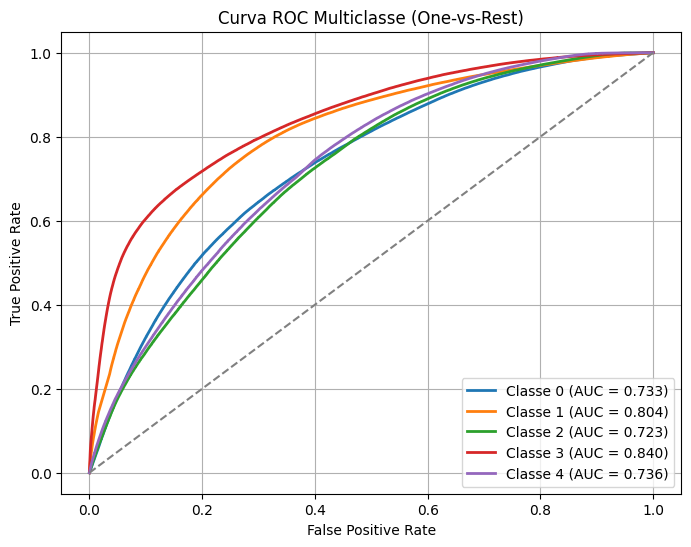

In [27]:
plt.figure(figsize=(8, 6))

for i in range(5):  # 5 classes
    fpr, tpr, _ = roc_curve(y_val_onehot[:, i], y_val_pred[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2,
             label=f"Classe {i} (AUC = {roc_auc:.3f})")

# Linha diagonal (azar)
plt.plot([0, 1], [0, 1], "--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC Multiclasse (One-vs-Rest)")
plt.legend()
plt.grid(True)
plt.show()


In [28]:
from tensorflow import keras
from tensorflow.keras import layers

input_dim = X_train_scaled.shape[1]  # número de features

model1 = keras.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(1000, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(500, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(250, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(5, activation='softmax')
])

model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model1.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 1000)           │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 250)            │       125,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │         1,255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 635,005 (2.42 MB)

 Trainable params: 635,005 (2.42 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:

history = model1.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=128,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/150
31875/31875 ━━━━━━━━━━━━━━━━━━━━ 116s 4ms/step - accuracy: 0.4450 - loss: 1.3137 - val_accuracy: 0.4673 - val_loss: 1.2657
Epoch 2/150
31875/31875 ━━━━━━━━━━━━━━━━━━━━ 102s 3ms/step - accuracy: 0.4613 - loss: 1.2824 - val_accuracy: 0.4705 - val_loss: 1.2631
Epoch 3/150
31875/31875 ━━━━━━━━━━━━━━━━━━━━ 102s 3ms/step - accuracy: 0.4627 - loss: 1.2800 - val_accuracy: 0.4688 - val_loss: 1.2638
Epoch 4/150
31875/31875 ━━━━━━━━━━━━━━━━━━━━ 101s 3ms/step - accuracy: 0.4630 - loss: 1.2791 - val_accuracy: 0.4707 - val_loss: 1.2626
Epoch 5/150
31875/31875 ━━━━━━━━━━━━━━━━━━━━ 103s 3ms/step - accuracy: 0.4631 - loss: 1.2784 - val_accuracy: 0.4703 - val_loss: 1.2620
Epoch 6/150
31875/31875 ━━━━━━━━━━━━━━━━━━━━ 102s 3ms/step - accuracy: 0.4639 - loss: 1.2780 - val_accuracy: 0.4683 - val_loss: 1.2613
Epoch 7/150
31875/31875 ━━━━━━━━━━━━━━━━━━━━ 102s 3ms/step - accuracy: 0.4637 - loss: 1.2780 - val_accuracy: 0.4697 - val_loss: 1.2613
Epoch 8/150
31875/31875 ━━━━━━━━━━━━━━━━━━━━ 102s 3ms/s

31875/31875 ━━━━━━━━━━━━━━━━━━━━ 42s 1ms/step


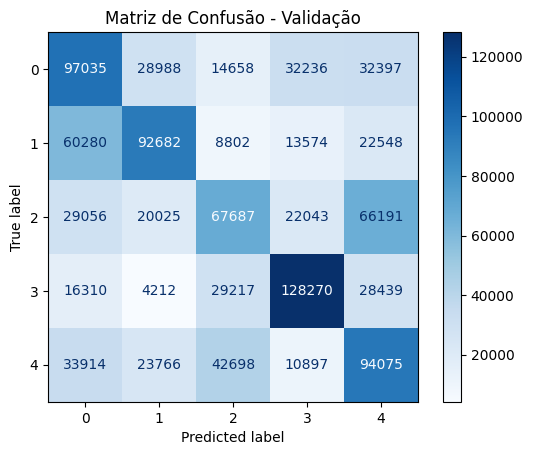

In [30]:

# Predições no conjunto de validação
y_val_pred = model1.predict(X_val_scaled)
y_val_pred_classes = np.argmax(y_val_pred, axis=1)

# Matriz de confusão
cm = confusion_matrix(y_val, y_val_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusão - Validação")
plt.show()


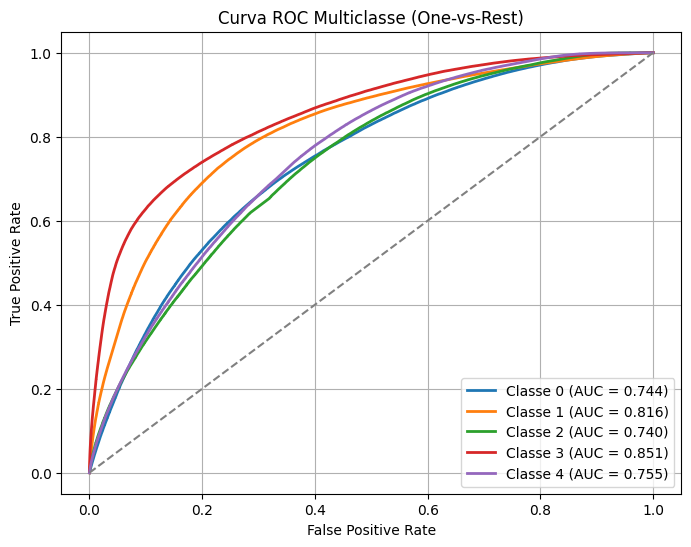

In [31]:
y_val_onehot = to_categorical(y_val, num_classes=5)
plt.figure(figsize=(8, 6))

for i in range(5):  # 5 classes
    fpr, tpr, _ = roc_curve(y_val_onehot[:, i], y_val_pred[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2,
             label=f"Classe {i} (AUC = {roc_auc:.3f})")

# Linha diagonal (azar)
plt.plot([0, 1], [0, 1], "--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC Multiclasse (One-vs-Rest)")
plt.legend()
plt.grid(True)
plt.show()


In [32]:
model2 = keras.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(1300, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(700, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(350, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(200, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(5, activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model2.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 1300)           │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1300)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 700)            │       910,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 700)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 350)            │       245,350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 350)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 200)            │        70,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 5)              │         1,005 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,237,655 (4.72 MB)

 Trainable params: 1,237,655 (4.72 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:

history = model2.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=128,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/150
31875/31875 ━━━━━━━━━━━━━━━━━━━━ 126s 4ms/step - accuracy: 0.4436 - loss: 1.3169 - val_accuracy: 0.4668 - val_loss: 1.2715
Epoch 2/150
31875/31875 ━━━━━━━━━━━━━━━━━━━━ 120s 4ms/step - accuracy: 0.4603 - loss: 1.2861 - val_accuracy: 0.4685 - val_loss: 1.2670
Epoch 3/150
31875/31875 ━━━━━━━━━━━━━━━━━━━━ 120s 4ms/step - accuracy: 0.4608 - loss: 1.2840 - val_accuracy: 0.4695 - val_loss: 1.2639
Epoch 4/150
31875/31875 ━━━━━━━━━━━━━━━━━━━━ 120s 4ms/step - accuracy: 0.4614 - loss: 1.2833 - val_accuracy: 0.4686 - val_loss: 1.2641
Epoch 5/150
31875/31875 ━━━━━━━━━━━━━━━━━━━━ 120s 4ms/step - accuracy: 0.4618 - loss: 1.2830 - val_accuracy: 0.4682 - val_loss: 1.2666
Epoch 6/150
31875/31875 ━━━━━━━━━━━━━━━━━━━━ 119s 4ms/step - accuracy: 0.4619 - loss: 1.2829 - val_accuracy: 0.4697 - val_loss: 1.2631
Epoch 7/150
31875/31875 ━━━━━━━━━━━━━━━━━━━━ 118s 4ms/step - accuracy: 0.4621 - loss: 1.2820 - val_accuracy: 0.4700 - val_loss: 1.2613
Epoch 8/150
31875/31875 ━━━━━━━━━━━━━━━━━━━━ 144s 4ms/s

31875/31875 ━━━━━━━━━━━━━━━━━━━━ 42s 1ms/step


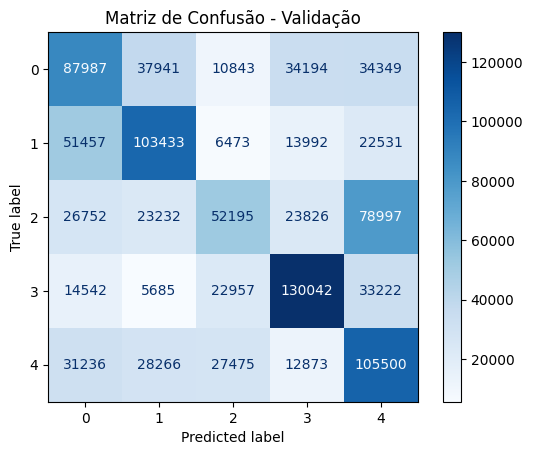

In [34]:

# Predições no conjunto de validação
y_val_pred = model2.predict(X_val_scaled)
y_val_pred_classes = np.argmax(y_val_pred, axis=1)

# Matriz de confusão
cm = confusion_matrix(y_val, y_val_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusão - Validação")
plt.show()


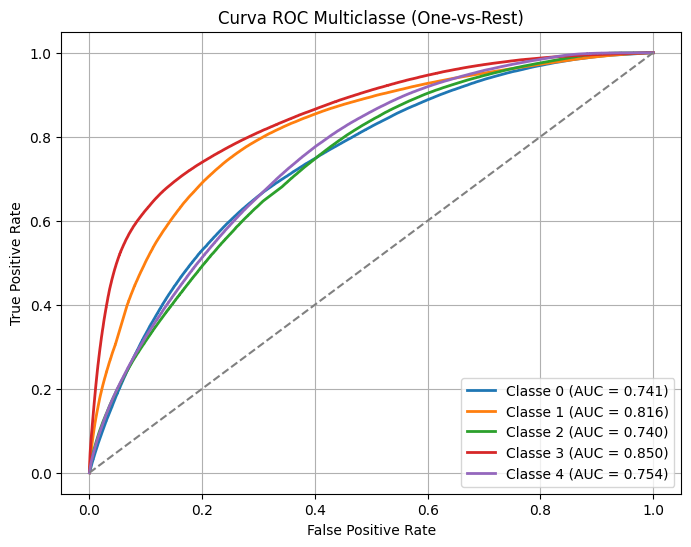

In [35]:
y_val_onehot = to_categorical(y_val, num_classes=5)
plt.figure(figsize=(8, 6))

for i in range(5):  # 5 classes
    fpr, tpr, _ = roc_curve(y_val_onehot[:, i], y_val_pred[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2,
             label=f"Classe {i} (AUC = {roc_auc:.3f})")

# Linha diagonal (azar)
plt.plot([0, 1], [0, 1], "--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC Multiclasse (One-vs-Rest)")
plt.legend()
plt.grid(True)
plt.show()
